# Experimento de 140 combinaciones, parte 7: interpretabilidad

¿En qué se apoyan los mejores modelos para predecir la aptitud? La hipótesis de partida es que latitud y longitud dominan, porque el índice
tiene un desplazamiento por región, y que después vienen la pendiente y la distancia a la carretera. Si SHAP la confirma, el modelo estaría
aprendiendo sobre todo dónde está la planta.

- SHAP reparte cada predicción entre las variables con valores de Shapley (Lundberg y Lee, 2017). En árboles, bosques y XGBoost se calcula
  exacto con TreeSHAP (Lundberg et al., 2020).
- LIME ajusta un modelo lineal alrededor de una observación, perturbándola (Ribeiro et al., 2016). Se compara con SHAP en XGBoost, como pide la guía.

Los modelos se reentrenan con los hiperparámetros elegidos en el primer pliegue externo y se explican sobre su prueba: plantas que el modelo no vio.

## Flujo del experimento

![Flujo del experimento](fig_pipeline_experimento.png)

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from src import analisis, balancing, config, cv, explain, models

maestra, res = analisis.cargar()
b = analisis.base()
NOMBRES = config.VARIABLES
tr, te = cv.externas(b.y_clf, b.grupos)[0]
rng = np.random.default_rng(config.SEED)
muestra = rng.choice(te, min(3000, len(te)), replace=False)  # SHAP sobre 3 mil plantas de prueba: suficiente para el resumen global

def reentrena(tarea, fila):
    f0 = maestra[(maestra.tarea == tarea) & (maestra.modelo == fila.modelo) & (maestra.balanceo == fila.balanceo)
                 & (maestra.optimizador == fila.optimizador) & (maestra.pliegue == 0)].iloc[0]
    params = {**json.loads(f0.params), **models.FINAL.get((tarea, fila.modelo), {})}
    bal = "ninguno" if fila.balanceo == "—" else fila.balanceo
    y = b.y_clf if tarea == "clf" else b.y_reg
    p = balancing.construir(models.estimador(tarea, fila.modelo), fila.modelo, bal).set_params(**{f"m__{k}": v for k, v in params.items()})
    return p.fit(b.X[tr], y[tr], **balancing.argumentos_fit(fila.modelo, bal, y[tr])), params

mej_c = analisis.mejores_por_modelo(res, "clf").sort_values("puntaje_interno", ascending=False)
mej_r = analisis.mejores_por_modelo(res, "reg").sort_values("puntaje_interno", ascending=False)
mc, mr = mej_c.iloc[0], mej_r.iloc[0]
pipe_c, par_c = reentrena("clf", mc)
pipe_r, par_r = reentrena("reg", mr)
print("Clasificación:", mc.modelo, mc.balanceo, mc.optimizador, par_c)
print("Regresión:", mr.modelo, mr.optimizador, par_r)

C:\Users\Enma\miniconda3\envs\solarpv-eda\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Clasificación: Random Forest ninguno aleatoria {'n_estimators': 96, 'max_features': 0.6212976120477064, 'min_samples_leaf': 2, 'max_samples': 0.870952855683138}
Regresión: Random Forest bayesiana {'n_estimators': 147, 'max_features': 0.7542239479217042, 'min_samples_leaf': 2, 'max_samples': 0.6839358624872616}


## 1. SHAP global, clasificación

Importancia media |SHAP| por clase y diagrama de enjambre para la clase Baja, la minoritaria. En el enjambre, cada punto es una planta: la
posición horizontal es cuánto empuja esa variable hacia Baja y el color, si el valor de la variable es alto o bajo.

,Baja,Media,Alta,media
longitude,0.0336,0.1924,0.2211,0.1491
aspect_cos,0.0041,0.0874,0.0885,0.0600
slope,0.0512,0.0281,0.0523,0.0438
latitude,0.0035,0.0217,0.0237,0.0163
log_dist_to_road,0.0015,0.0089,0.0091,0.0065
ghi,0.0007,0.0068,0.0065,0.0047
curvature,0.0011,0.0057,0.0065,0.0044
elevation,0.0010,0.0055,0.0060,0.0042
ambient_temperature,0.0005,0.0061,0.0059,0.0041
wind_speed,0.0010,0.0058,0.0055,0.0041


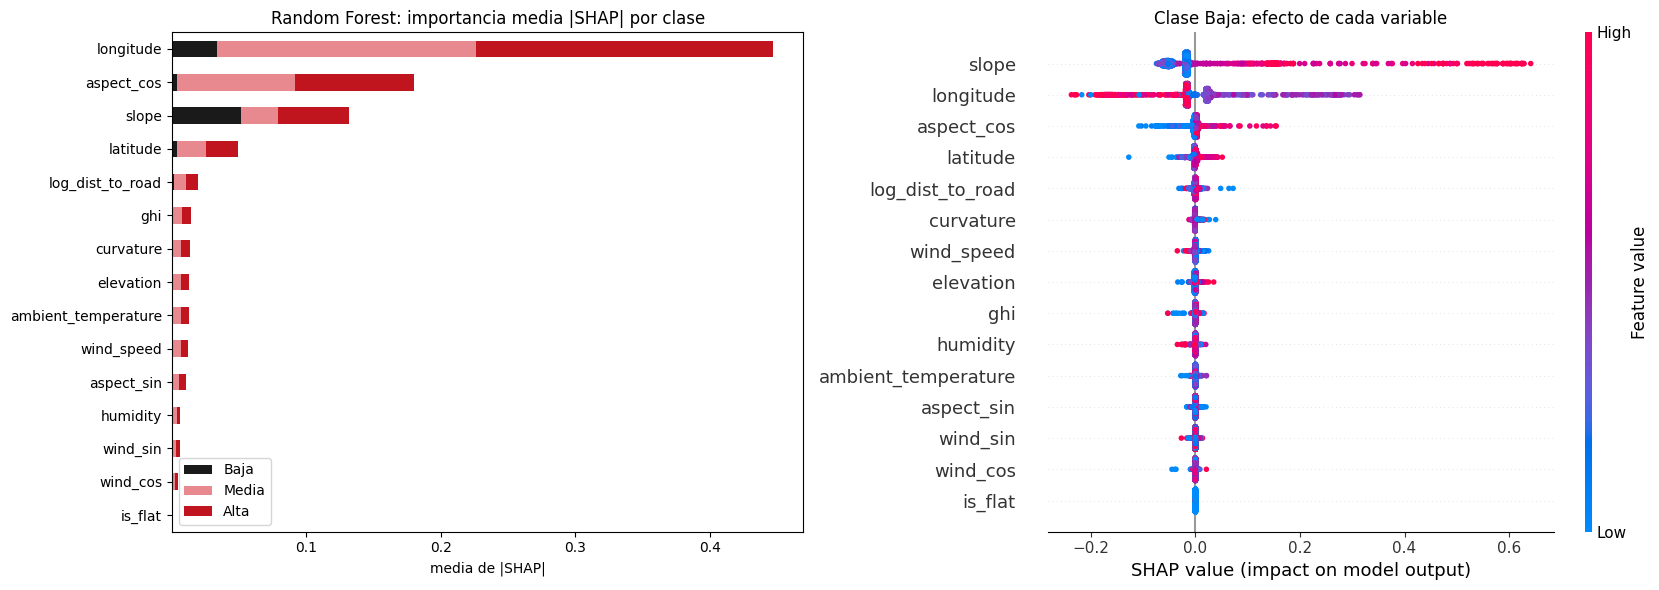

In [2]:
exp_c = explain.valores_shap(pipe_c, b.X[muestra], NOMBRES, fondo=b.X[tr])
vals = exp_c.values if exp_c.values.ndim == 3 else exp_c.values[..., None]
imp = pd.DataFrame(np.abs(vals).mean(0), index=NOMBRES, columns=config.CLASES[:vals.shape[2]] if vals.shape[2] == 3 else ["salida"])
imp["media"] = imp.mean(1)
imp = imp.sort_values("media", ascending=False)
display(imp.round(4))

fig, axes = plt.subplots(1, 2, figsize=(17, 6))
imp.drop(columns="media").iloc[::-1].plot.barh(ax=axes[0], stacked=True, color=["#1A1A1A", "#E8898F", "#C0141F"][:imp.shape[1] - 1])
axes[0].set_title(f"{mc.modelo}: importancia media |SHAP| por clase"); axes[0].set_xlabel("media de |SHAP|")
plt.sca(axes[1])
shap.plots.beeswarm(exp_c[:, :, 0] if exp_c.values.ndim == 3 else exp_c, max_display=15, show=False, plot_size=None)
axes[1].set_title("Clase Baja: efecto de cada variable")
fig.tight_layout(); fig.savefig("fig_exp_shap_clf.png", dpi=130, bbox_inches="tight"); plt.show()

## 2. SHAP global, regresión

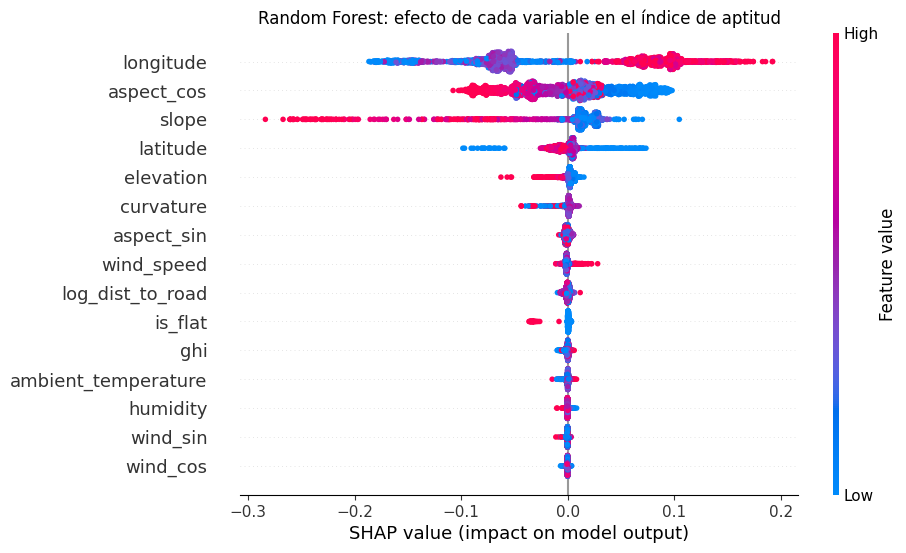

,media |SHAP|
longitude,0.0827
aspect_cos,0.0409
slope,0.0267
latitude,0.0077
elevation,0.0041
curvature,0.0025
aspect_sin,0.0016
wind_speed,0.0015
log_dist_to_road,0.0014
is_flat,0.0011


In [3]:
exp_r = explain.valores_shap(pipe_r, b.X[muestra], NOMBRES, fondo=b.X[tr])
fig = plt.figure(figsize=(9, 6))
shap.plots.beeswarm(exp_r, max_display=15, show=False, plot_size=None)
plt.title(f"{mr.modelo}: efecto de cada variable en el índice de aptitud")
fig.savefig("fig_exp_shap_reg.png", dpi=130, bbox_inches="tight"); plt.show()
pd.Series(np.abs(exp_r.values).mean(0), index=NOMBRES).sort_values(ascending=False).rename("media |SHAP|").round(4).to_frame()

## 3. Dos observaciones explicadas

En regresión, una planta donde el modelo acierta y una donde se equivoca mucho. El gráfico de cascada parte del valor medio que predice el
modelo y suma la contribución de cada variable hasta llegar a la predicción de esa planta.

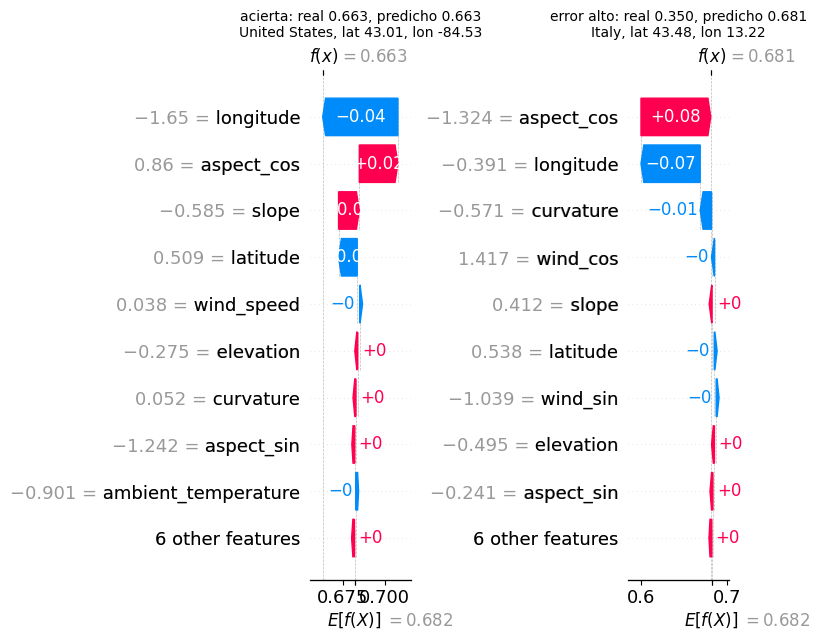

In [4]:
pred = pipe_r.predict(b.X[muestra])
err = np.abs(b.y_reg[muestra] - pred)
i_bien, i_mal = int(np.argmin(err)), int(np.argmax(err))
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
for ax, i, titulo in zip(axes, [i_bien, i_mal], ["acierta", "error alto"]):
    plt.sca(ax)
    shap.plots.waterfall(exp_r[i], max_display=10, show=False)
    t = b.tabla.iloc[muestra[i]]
    ax.set_title(f"{titulo}: real {b.y_reg[muestra[i]]:.3f}, predicho {pred[i]:.3f}\n{t.country}, lat {t.latitude:.2f}, lon {t.longitude:.2f}", fontsize=10)
fig.tight_layout(); fig.savefig("fig_exp_shap_cascada.png", dpi=130, bbox_inches="tight"); plt.show()

## 4. LIME frente a SHAP en XGBoost

Para el XGBoost de clasificación (su mejor combinación) se explica la probabilidad de la clase predicha en 30 plantas de prueba: las dos de la
sección anterior y 28 al azar. Por planta se mide la correlación de Spearman entre las dos atribuciones y cuántas de las 5 variables más
importantes comparten. Si coinciden, la explicación es más creíble; donde divergen suele haber interacciones fuertes o una frontera de clase cerca.

,planta,confianza,Spearman,top 5 en común
count,30.000,30.000,30.000,30.000
mean,26832.267,0.873,-0.304,3.100
std,18834.944,0.114,0.247,0.662
min,128.000,0.598,-0.793,2.000
25%,10508.000,0.809,-0.445,3.000
50%,23662.000,0.883,-0.332,3.000
75%,47072.250,0.987,-0.154,3.750
max,51824.000,0.995,0.268,4.000


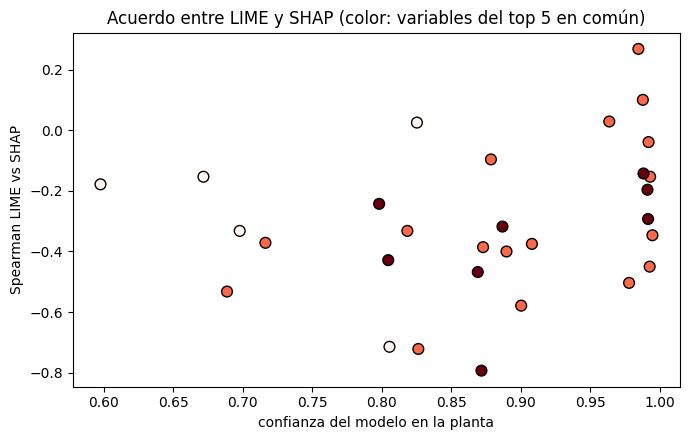

In [5]:
if "XGBoost" in mej_c.index:
    pipe_x, _ = reentrena("clf", mej_c.loc["XGBoost"])
    idx = [muestra[i_bien], muestra[i_mal]] + list(rng.choice(muestra, 28, replace=False))
    exp_x = explain.valores_shap(pipe_x, b.X[idx], NOMBRES)
    clase = pipe_x.predict(b.X[idx])
    filas = []
    for j, (fila, c) in enumerate(zip(idx, clase)):
        r = explain.lime_vs_shap(pipe_x, b.X[tr][::10], b.X[fila], NOMBRES, int(c), exp_x.values[j, :, int(c)])
        conf = pipe_x.predict_proba(b.X[[fila]])[0].max()
        filas.append({"planta": fila, "clase predicha": config.CLASES[int(c)], "confianza": conf, "Spearman": r["spearman"],
                      "top 5 en común": r["coinciden_top5"]})
    lv = pd.DataFrame(filas)
    display(lv.describe().round(3))
    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.scatter(lv.confianza, lv.Spearman, c=lv["top 5 en común"], cmap="Reds", s=60, edgecolor="k")
    ax.set_xlabel("confianza del modelo en la planta"); ax.set_ylabel("Spearman LIME vs SHAP")
    ax.set_title("Acuerdo entre LIME y SHAP (color: variables del top 5 en común)")
    fig.tight_layout(); fig.savefig("fig_exp_lime_shap.png", dpi=130, bbox_inches="tight"); plt.show()
else:
    print("XGBoost todavía no tiene combinaciones completas.")

## 5. Interpretación

La hipótesis de partida se cumple en parte. En el Random Forest de clasificación y en el de regresión, `longitude` es la variable que más pesa (importancia media de |SHAP| de 0.149 en clasificación y 0.083 en regresión), con una distancia grande sobre la siguiente. `latitude` pesa menos de lo esperado y queda cuarta (0.016 y 0.008). Entre `longitude` y `latitude` quedan `aspect_cos` (0.060 y 0.041) y `slope` (0.044 y 0.027), que sí entran en la fórmula del índice. `log_dist_to_road` aparece en quinto lugar en clasificación (0.0065), y las variables de clima (`ghi`, temperatura, humedad) quedan por debajo de 0.005 en clasificación y de 0.002 en regresión. En la clase Baja, la variable más importante es `slope` (0.051) y después `longitude` (0.034). Con la longitud tan por delante, el modelo se apoya sobre todo en dónde está la planta, como se esperaba desde el EDA.

LIME y SHAP se parecen poco en el XGBoost de clasificación. En las 30 plantas, la correlación de Spearman entre las dos atribuciones tiene un promedio de -0.30 (de -0.79 a 0.27), y comparten en promedio 3.1 de las 5 variables más importantes (entre 2 y 4). LIME ajusta una pendiente local y SHAP reparte la predicción entre las variables, así que sus valores no son magnitudes equivalentes.

## Referencias

- Lundberg, S. M. y Lee, S.-I. (2017). A unified approach to interpreting model predictions. *Advances in Neural Information Processing Systems, 30*.
- Lundberg, S. M., Erion, G., Chen, H., DeGrave, A., Prutkin, J. M., Nair, B., Katz, R., Himmelfarb, J., Bansal, N. y Lee, S.-I. (2020). From local explanations to global understanding with explainable AI for trees. *Nature Machine Intelligence, 2*, 56-67. https://doi.org/10.1038/s42256-019-0138-9
- Ribeiro, M. T., Singh, S. y Guestrin, C. (2016). "Why should I trust you?": Explaining the predictions of any classifier. En *Proceedings of the 22nd ACM SIGKDD* (pp. 1135-1144). https://doi.org/10.1145/2939672.2939778